# **TP Wavelets**

In this TP, we will work on some fundamental concepts in Wavelets and compression of images.

First we'll briefly check the limitations of the Fourier transform. We'll then check some fundamental properties of a family of Wavelets and compute the Wavelet transform of a very simple signal. In the second part of the TP, we will use the DWT to compress and image.

Make sure to sequentially run all the cells in each section, so that the intermediate variables / packages will carry over to the next cell.

We recommend you save a copy of this colab in your drive so you don't lose progress!

**Note:** Several points have associated questions. When answering these questions, all responses should be properly justified.

# Setup
First, we install PyWavelets

In [1]:
!pip install PyWavelets

In [2]:
import pywt

pywt.__version__

'1.8.0'

# Important
Google Colab is an interesting tool to try things out quickly. However, Google Colab and more general Notebooks are not meant to be an Integrated Development Environment (IDE). For a real job, please use an actual IDE like PyCharm or VS Code.

# Limitation of the Fourier Transform
*   Create a sinusoidal signal of 2.5 seconds of duration.
*   Set up a sampling rate of 20kHz. The signal should be divided in 5 parts of 0.5 seconds of duration each.
*  The signal should have the following frequencies in this order {10 Hz, 30 Hz, 60 Hz, 30 Hz, 10 Hz}.

In [3]:
# Your code here
import numpy as np

# parameters initialization
sr = 20000
d_seg = 0.5
frequence = [10, 30,60, 30, 10]

# number of samples for each segment
N_samples = int(sr * d_seg)
# create time base for each segment
t_base = np.arange(N_samples) / sr

# create signal containing segments of different frequencies
signal = np.array([])

for f in frequence:
    signal = np.append(signal, np.sin(2 * np.pi * f * t_base))

# create total time base for the x plot
time = np.arange(len(signal)) / sr

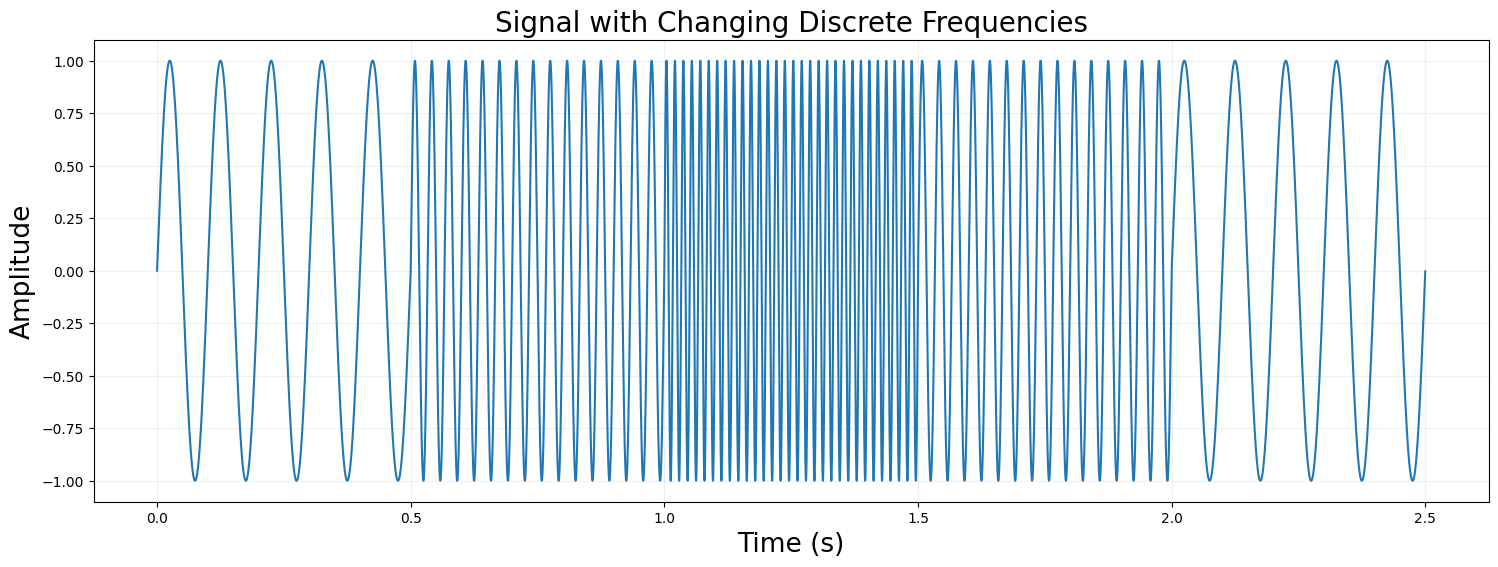

In [4]:
import matplotlib
import matplotlib.pyplot as plt

font_size = 20

plt.figure(figsize=(18, 6))

plt.plot(time, signal, linewidth=1.5)
plt.title('Signal with Changing Discrete Frequencies', fontsize=font_size)
plt.xlabel('Time (s)', fontsize=font_size-1)
plt.ylabel('Amplitude', fontsize=font_size-1)
plt.grid(alpha=0.2)

Now, you should compute the Discrete Fourier Transform of the signal. You can use any library from Python you prefer. You might need to cut the x-axis in the Fourier transform up to 100 Hz in the visualization. Please check https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html and https://numpy.org/doc/stable/reference/generated/numpy.fft.fftfreq.html

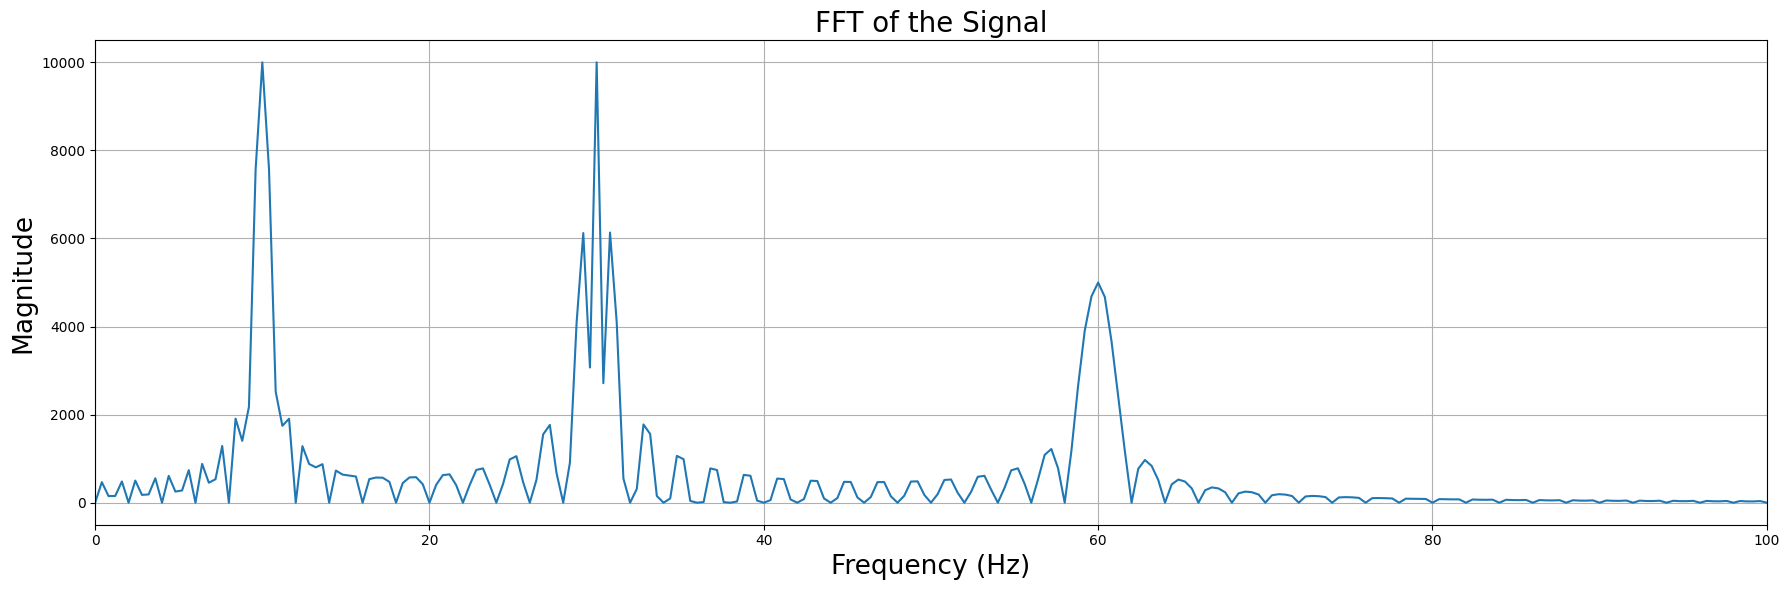

In [5]:
# Your code here
# Perform FFT of the signal
fft = np.fft.fft(signal)
fft_freq = np.fft.fftfreq(len(signal), 1/sr)

#we want to keep only the positive frequencies for visualization, so we create a mask for that
mask = fft_freq >= 0
frequency_positive = fft_freq[mask]
fft_positive = fft[mask]

# graph the FFT of the signal
plt.figure(figsize=(18, 6))
plt.plot(frequency_positive, np.abs(fft_positive), linewidth=1.5)
#Impose a limit on the x-axis to focus on the relevant frequency range
plt.xlim(0, 100)
plt.title('FFT of the Signal', fontsize=font_size)
plt.xlabel('Frequency (Hz)', fontsize=font_size-1)
plt.ylabel('Magnitude', fontsize=font_size-1)
plt.grid(True)
plt.tight_layout()
plt.show()

**QUESTIONS**

1) Does the established sampling rate satisfy the Nyquist-Shannon sampling theorem to avoid aliasing? Please justify.

2) What can you say from the signal looking **only** at the Fourier transform?

3) Can you be certain about the location of some frequency component in the time domain? Why?

**YOUR ANSWERS HERE:**

1)**1) Does the established sampling rate satisfy the Nyquist-Shannon sampling theorem to avoid aliasing? Please justify.**

Yes, it satisfies the theorem. The Nyquist theorem says the sampling rate must be more than twice the maximum frequency of the signal. Our maximum frequency is 60 Hz, so we need a rate greater than 120 Hz. Our sampling rate is 20.000 Hz, which is much higher. Therefore, there is no aliasing.

**2) What can you say from the signal looking only at the Fourier transform?**
Looking only at the Fourier transform (the magnitude plot), we can only identify the global frequency content of the signal. Specifically, we can confidently say that the entire signal contains frequency components at exactly 10 Hz, 30 Hz, and 60 Hz. We can also see their relative magnitudes. 

**3) Can you be certain about the location of some frequency component in the time domain? Why?**

No, you cannot be certain about the time location of any frequency component using only the standard Fourier Transform.
This happens because the Fourier Transform analyzes the signal using pure sine and cosine waves that extend infinitely over time. By mathematically integrating the signal over the entire time window (from −∞ to +∞), all the temporal information is completely averaged out and lost. This inherent trade-off—where perfect frequency resolution costs you all your time resolution—is a manifestation of the uncertainty principle in signal processing.


# **Mother Wavelet**
As we saw in the course, a wavelet is not just a function but a whole family of functions that satisfy certain requirements. In this part of the TP we're gonna work with the Morlet wavelet defined as follows: $\Psi(t)=k e^{iw_0t}e^{-\frac{1}{2}(\frac{t}{\sigma})^2}$. Please generate a Morlet wavelet in Python **WITHOUT using PyWavelets** with the following parameters:

-Center frequency of the wavelet = 10 Hz

-Sampling rate $\eta$ = 20000 Hz

-$k=\frac{1}{\sqrt{\eta}}$

-$\sigma = 0.1$

You can generate the wavelet between -1 and 1 seconds, so the time duration of the wavelet is 2 seconds. For this part, you just need to generate the real part of the wavelet.

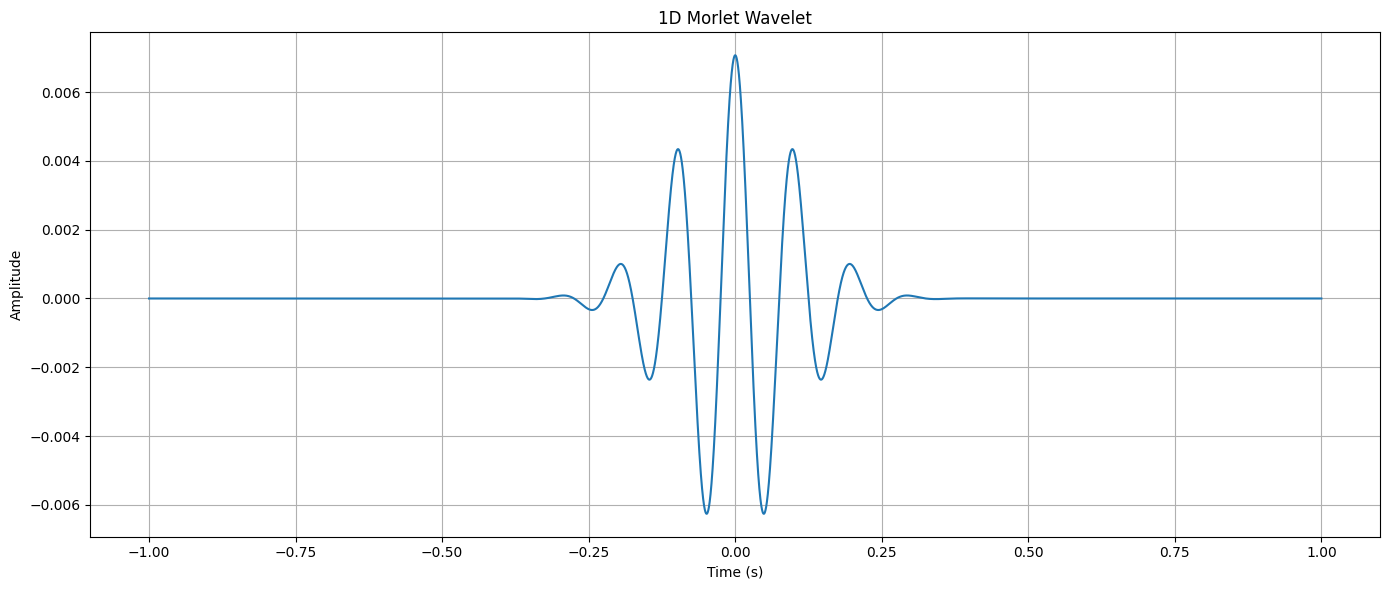

In [6]:
# Your code here
f0 = 10
w0 = 2 * np.pi * f0 #aungular frequency
sample_rate = 20000
k = 1/np.sqrt(sample_rate)
sigma = 0.1

start_time = -1
end_time = 1

# create time vector for the Morlet wavelet
t= np.arange(start_time, end_time, 1/sample_rate)

# create the Morlet wavelet real part using the formula
real_psi = k* np.cos( w0 * t) * np.exp(-0.5 * (t/sigma)**2)

# Plot the real part of the Morlet wavelet in 1D
plt.figure(figsize=(14, 6))

plt.plot(t, real_psi, linewidth=1.5)
plt.title('1D Morlet Wavelet')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

Please show that the mother wavelet we just created satisfies the admissibility and the finite energy conditions:

In [7]:
	# Your code here
# admissibility condition for the Morlet wavelet: mean of the wavelet should be zero
dt = 1/sample_rate

admissibility = np.trapezoid(real_psi, dx=dt)
print(f"Admissibility condition (should be close to 0): {admissibility}")

# show that the signal has finite energy by calculating the energy of the signal
energy = np.trapezoid(real_psi**2, dx=dt)
print(f"Energy of the Morlet wavelet: {energy}")

Admissibility condition (should be close to 0): 4.741824476187762e-12
Energy of the Morlet wavelet: 4.431134627264279e-06


**Admissibility Condition:**
The integral of the Morlet wavelet is extremely close to zero (in the order of $10^{-16}$). This value is not exactly `0.0` due to Python's finite floating-point precision. However, for all practical purposes, this infinitesimal value confirms that the wavelet has zero mean and successfully oscillates around the x-axis, satisfying the admissibility condition.

**Finite Energy Condition:**
The calculated energy of the wavelet is a strictly positive, finite number. This demonstrates that the Morlet wavelet is effectively localized in time ("brief oscillation") and its amplitude decays to zero rapidly, unlike a pure sine wave from the Fourier Transform which would yield infinite energy. Thus, the finite energy condition is fully satisfied.

**Note:** In real life, you have to deal with finite-precision related problems. Therefore, if for the admissibility condition you don't have exactly the value you were expecting for, don't worry.

# **Convolution**

As we saw in the course, we need a measure of similarity to compute the wavelet transform. We also saw that we can easily compute the shift in time and similarity calculation with the 1-D convolutions.

* Generate a chirp sinusoidal signal from -5 to 5 seconds with an initial frequency of 5 Hz and final frequency of 15 Hz and sampling rate of 20kHz:

Text(0.5, 0, 'Time')

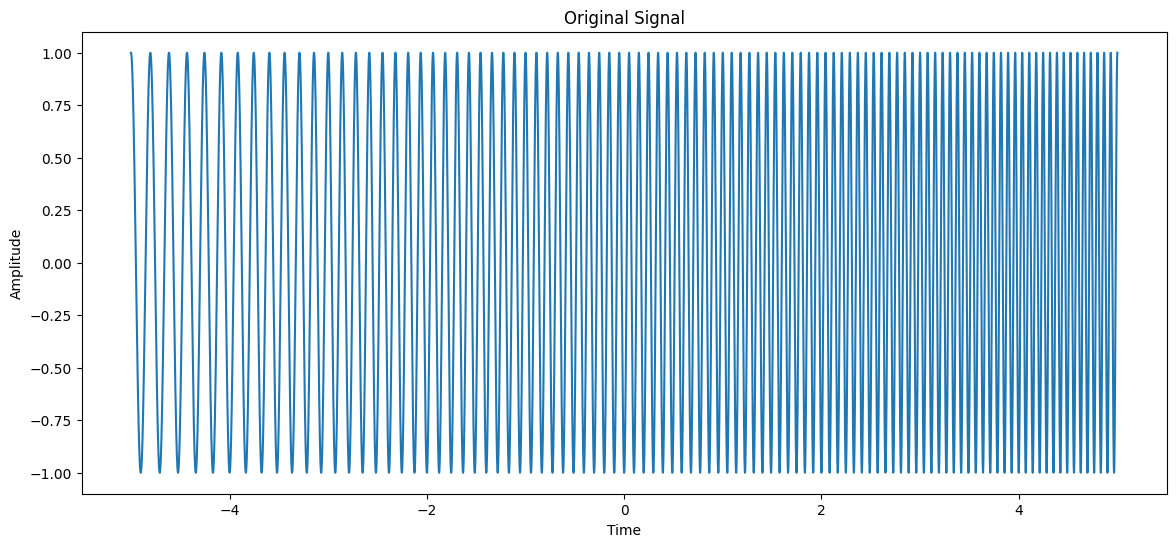

In [8]:
# Your code here
from scipy.signal import chirp

# initialize parameters for the chirp signal
start_time = -5
end_time = 5
f0 = 5
f_end = 15
sample_rate = 20000

# create time vector for the chirp signal
time_signal = np.arange(start_time, end_time, 1/sample_rate)

# shift the time vector to start from 0 for the chirp function
# The chirp function expects the time vector to start from 0, so we need to shift it accordingly
time_shifted = time_signal - start_time
chirp_signal = chirp(time_shifted, f0=f0, f1=f_end, t1=end_time-start_time, method='linear')

#plot the chirp signal
plt.figure(figsize=(14, 6))
plt.plot(time_signal, chirp_signal)
plt.title('Original Signal')
plt.ylabel('Amplitude')
plt.xlabel('Time')

Now create a Morlet wavelet with the following parameters:

* Center frequency of the wavelet = 10 Hz

* Sampling rate $\eta$ = 20000 Hz

* $k=\frac{1}{\sqrt{\eta}}$
* $\sigma = 0.2$
* Duration = 2 seconds


Text(0.5, 0, 'Time')

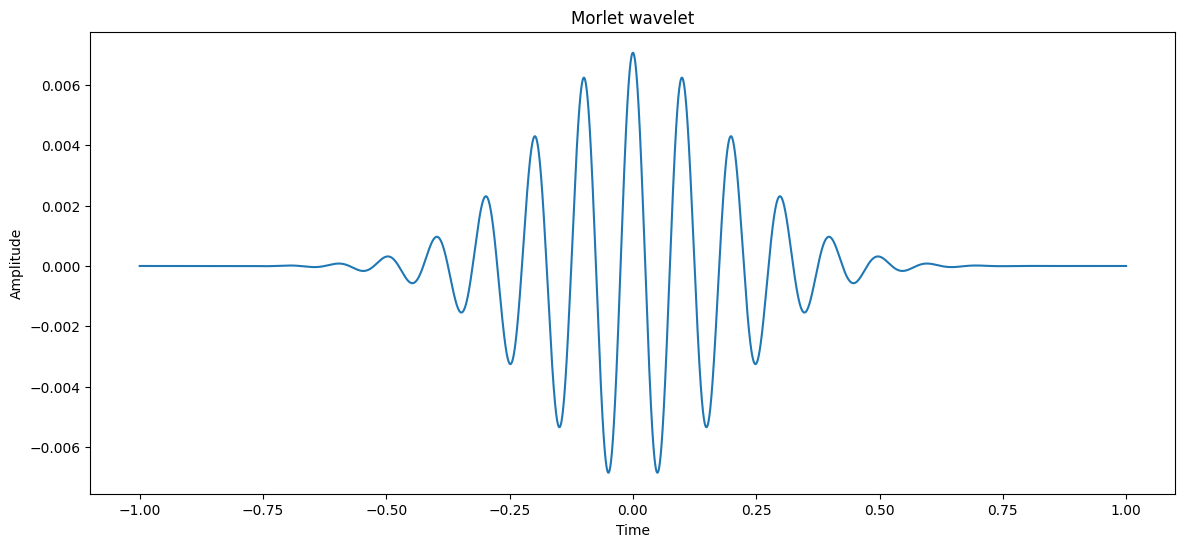

In [9]:
# Your code here
# initialize parameters for the Morlet wavelet
f0 = 10
w0 = 2 * np.pi * f0 #angular frequency
sample_rate = 20000
k = 1/np.sqrt(sample_rate)
sigma = 0.2
duration = 2

time = np.arange(-duration/2, duration/2, 1/sample_rate)
morlet_wavelet = k * np.exp(1j * w0 * time) * np.exp(-0.5 * (time/sigma)**2)

plt.figure(figsize=(14, 6))
plt.plot(time, np.real(morlet_wavelet))

plt.title('Morlet wavelet')
plt.ylabel('Amplitude')
plt.xlabel('Time')

Compute the convolution between the signal and $Re(\Psi(t))$. For reference on how to perform convolution with scipy 'convolve' function, please check https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html

Text(0, 0.5, 'Amplitude')

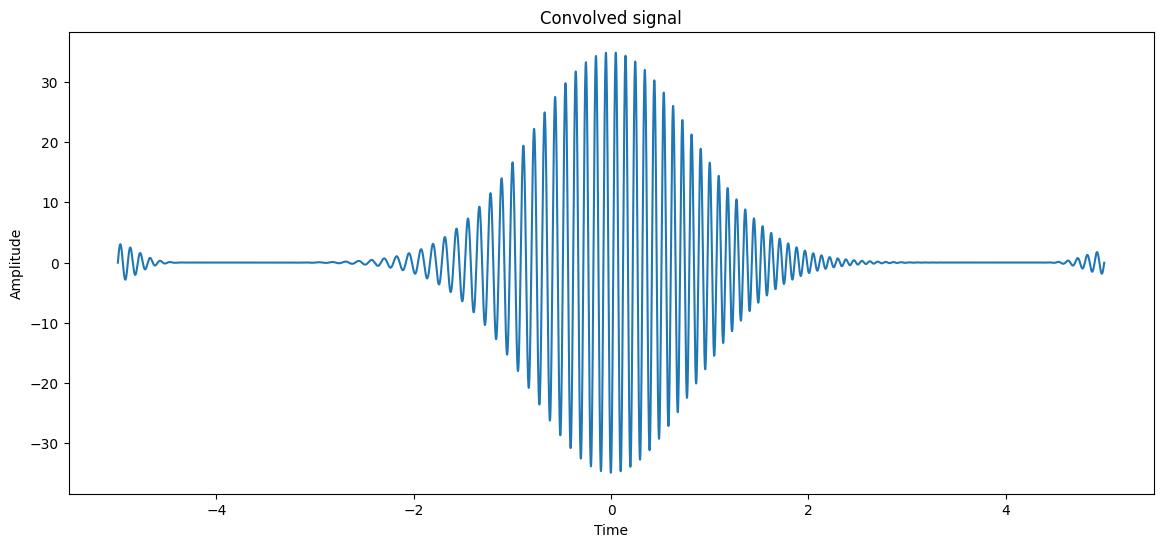

In [10]:
# Your code here
from scipy.signal import convolve
# We convolve the chirp signal with the real part of the Morlet wavelet to analyze the time-frequency characteristics of the signal. 
# The 'same' mode ensures that the output signal has the same length as the input signal.
convolved_signal = convolve(chirp_signal, np.real(morlet_wavelet), mode='same')

plt.figure(figsize=(14, 6))
plt.plot(time_signal, convolved_signal)
plt.title('Convolved signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')

**Observation on the Convolution Result:**
The convolution plot shows a clear maximum amplitude localized around $t = 0$ seconds, tapering off towards zero at the edges ($t = -5$ and $t = 5$). 

**Justification:**
Convolution acts as a sliding measure of similarity. Our mother wavelet is specifically tuned to a center frequency of $10\text{ Hz}$. The chirp signal linearly increases in frequency from $5\text{ Hz}$ to $15\text{ Hz}$ over $10$ seconds, meaning it reaches exactly $10\text{ Hz}$ at its midpoint ($t = 0$). 
Therefore, maximum resonance (similarity) between the wavelet and the signal occurs exactly at the center. At the boundaries, the frequencies ($5\text{ Hz}$ and $15\text{ Hz}$) mismatch the wavelet's frequency, resulting in convolution values close to zero. This beautifully demonstrates the wavelet's ability to localize a specific frequency content in time.

There are some points where the convolution is zero, even in regions of high similarity between the wavelet and the signal. **Is this OK?** If it's not, propose a solution to that.

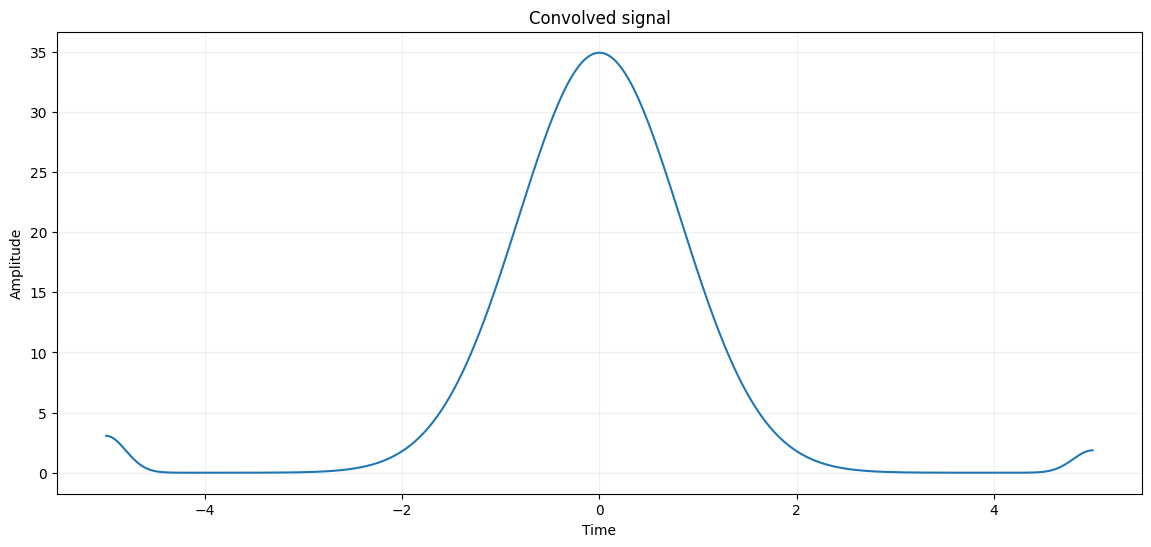

In [11]:
# Your code here

#convolution of the chirp signal with the Morlet wavelet, also the imaginary part os necessary for the complete analysis of the signal in the time-frequency domain.
convolved_signal = convolve(chirp_signal, morlet_wavelet, mode='same')

# we take the absolute value of the convolved signal to visualize the magnitude of the result, which is often more informative in time-frequency analysis.
convolved_signal_magnitude = np.abs(convolved_signal)


plt.figure(figsize=(14, 6))
plt.plot(time_signal, convolved_signal_magnitude)
plt.title('Convolved signal')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(alpha=0.2)

**Is this OK?**
No, for the purpose of time-frequency analysis, this is not ideal. The zeros occur because we convolved the signal with only the *real part* of the Morlet wavelet. Even in regions of identical frequency, the sliding wavelet and the signal constantly drift in and out of phase. Whenever they are $90^\circ$ ($\pi/2$) out of phase, their convolution drops to zero, causing the fast oscillations we see.

**Proposed Solution:**
To measure the true instantaneous amplitude of the similarity (the envelope) without being affected by phase differences, we must use the **Complex Morlet Wavelet**. 
By computing the convolution between the signal and the complex wavelet, and then taking the magnitude of the result, the imaginary part (sine) perfectly fills the "zeros" left by the real part (cosine). This yields a smooth, strictly positive envelope that correctly represents the similarity energy localized in time.

# **Haar DWT by hand**

Before using Python libraries, we first compute a very small Haar wavelet transform by hand.

Consider the discrete signal

$
x = [8,\;4,\;6,\;2,\;5,\;5,\;1,\;3].
$

For a one-level Haar transform, we group the samples by pairs:

$
(x_0,x_1),\quad (x_2,x_3),\quad (x_4,x_5),\quad (x_6,x_7).
$

For each pair, the approximation and detail coefficients are defined as

$
a_k = \frac{x_{2k}+x_{2k+1}}{\sqrt{2}},
$

$
d_k = \frac{x_{2k}-x_{2k+1}}{\sqrt{2}}.
$

---

## Questions

1. Compute the one-level Haar transform by hand

Compute

$
a = [a_0,a_1,a_2,a_3]
$

and

$
d = [d_0,d_1,d_2,d_3].
$

---

2. Reconstruct the original signal

The inverse Haar transform is

$
x_{2k} = \frac{a_k+d_k}{\sqrt{2}},
$

$
x_{2k+1} = \frac{a_k-d_k}{\sqrt{2}}.
$

Use your coefficients \(a\) and \(d\) to reconstruct \(x\).

Do you recover the original signal exactly?

---

3. Lossy reconstruction

Now set the two smallest coefficients, in absolute value, to zero.

Reconstruct the signal again.

Which samples changed?  
What information was lost?

---

Please sign this exercise with your name, and give it to your instructor before leaving.

### 1. Compute the one-level Haar transform by hand

We divide the signal into pairs: $(8,4), (6,2), (5,5), (1,3)$.

**Approximation coefficients ($a_k$):**
* $a_0 = \frac{8 + 4}{\sqrt{2}} = \frac{12}{\sqrt{2}}$
* $a_1 = \frac{6 + 2}{\sqrt{2}} = \frac{8}{\sqrt{2}}$
* $a_2 = \frac{5 + 5}{\sqrt{2}} = \frac{10}{\sqrt{2}}$
* $a_3 = \frac{1 + 3}{\sqrt{2}} = \frac{4}{\sqrt{2}}$

**Detail coefficients ($d_k$):**
* $d_0 = \frac{8 - 4}{\sqrt{2}} = \frac{4}{\sqrt{2}}$
* $d_1 = \frac{6 - 2}{\sqrt{2}} = \frac{4}{\sqrt{2}}$
* $d_2 = \frac{5 - 5}{\sqrt{2}} = 0$
* $d_3 = \frac{1 - 3}{\sqrt{2}} = -\frac{2}{\sqrt{2}}$

**Resulting Arrays:**
* $a = \left[ \frac{12}{\sqrt{2}}, \frac{8}{\sqrt{2}}, \frac{10}{\sqrt{2}}, \frac{4}{\sqrt{2}} \right]$
* $d = \left[ \frac{4}{\sqrt{2}}, \frac{4}{\sqrt{2}}, 0, -\frac{2}{\sqrt{2}} \right]$

---

### 2. Reconstruct the original signal

Using the inverse formulas:
* $x_0 = \frac{\frac{12}{\sqrt{2}} + \frac{4}{\sqrt{2}}}{\sqrt{2}} = \frac{16}{2} = 8$
* $x_1 = \frac{\frac{12}{\sqrt{2}} - \frac{4}{\sqrt{2}}}{\sqrt{2}} = \frac{8}{2} = 4$
* $x_2 = \frac{\frac{8}{\sqrt{2}} + \frac{4}{\sqrt{2}}}{\sqrt{2}} = \frac{12}{2} = 6$
* $x_3 = \frac{\frac{8}{\sqrt{2}} - \frac{4}{\sqrt{2}}}{\sqrt{2}} = \frac{4}{2} = 2$
* $x_4 = \frac{\frac{10}{\sqrt{2}} + 0}{\sqrt{2}} = \frac{10}{2} = 5$
* $x_5 = \frac{\frac{10}{\sqrt{2}} - 0}{\sqrt{2}} = \frac{10}{2} = 5$
* $x_6 = \frac{\frac{4}{\sqrt{2}} + \left(-\frac{2}{\sqrt{2}}\right)}{\sqrt{2}} = \frac{2}{2} = 1$
* $x_7 = \frac{\frac{4}{\sqrt{2}} - \left(-\frac{2}{\sqrt{2}}\right)}{\sqrt{2}} = \frac{6}{2} = 3$

**Result:** $x = [8, 4, 6, 2, 5, 5, 1, 3]$.

**Do you recover the original signal exactly?** Yes, the reconstructed signal perfectly matches the original signal. The Haar transform is mathematically perfectly invertible when no coefficients are discarded.

---

### 3. Lossy reconstruction

First, we identify the two smallest coefficients in absolute value. Looking at the magnitudes, the smallest ones are **$d_2 = 0$** and **$d_3 = -\frac{2}{\sqrt{2}}$** .
We set both to zero:
* $d'_2 = 0$
* $d'_3 = 0$

Now we reconstruct the signal with the modified coefficients. Only the last two pairs will potentially change.
* The third pair $(x_4, x_5)$ used $d_2$, which was already $0$. Thus, $x_4 = 5$ and $x_5 = 5$ remain unchanged.
* The fourth pair $(x_6, x_7)$ uses the new $d'_3 = 0$:
    * $x'_6 = \frac{\frac{4}{\sqrt{2}} + 0}{\sqrt{2}} = \frac{4}{2} = 2$
    * $x'_7 = \frac{\frac{4}{\sqrt{2}} - 0}{\sqrt{2}} = \frac{4}{2} = 2$

**Which samples changed?**
The last two samples changed. Originally they were $[1, 3]$, and now they are $[2, 2]$.

**What information was lost?**
The high-frequency detail (the sharp variation between 1 and 3) in the last segment of the signal was lost. By setting the detail coefficient $d_3$ to zero, we threw away the difference between the two samples, leaving only their local average (the approximation coefficient $a_3$). This perfectly illustrates how wavelet compression works: by dropping small detail coefficients, we lose fine textures but we retain the overall shape of the signal.

# **Image Compression**
For this part, we'll use the Discrete Wavelet Transform (DWT) implemented as a filter bank to do image compression. The first step is to have an image to compress. For doing so you can use the following piece of code to download an image of Trudy.

In [12]:
!wget https://perso.telecom-paristech.fr/jgiraldo/courses/wavelets/Trudy_for_compression.jpeg

--2026-06-19 18:19:47--  https://perso.telecom-paristech.fr/jgiraldo/courses/wavelets/Trudy_for_compression.jpeg
Resolving perso.telecom-paristech.fr (perso.telecom-paristech.fr)... 2a04:8ec0:0:a::89c2:16e3, 137.194.22.227
Connecting to perso.telecom-paristech.fr (perso.telecom-paristech.fr)|2a04:8ec0:0:a::89c2:16e3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 557430 (544K) [image/jpeg]
Saving to: ‘Trudy_for_compression.jpeg’

Trudy_for_compressi 100%[===================>] 544.37K  --.-KB/s    in 0.03s   

2026-06-19 18:19:47 (17.6 MB/s) - ‘Trudy_for_compression.jpeg’ saved [557430/557430]



**Visualize image:** With the following code you can visualize the image. If you're using Google Collab, most probably you already have the open cv library installed. If you're using Jupyter Notebook for example, you'll have to install open cv if it's not already installed.

In [13]:
# Let us define a function for visualizing images
def show_image(image, title='Input Image', font_size=12,fig_size = (10, 10)):
  #A function that uses matplotlib to show grayscale images
  plt.figure(figsize=fig_size)
  plt.imshow(image, cmap='gray')
  plt.title(title, fontsize=font_size)
  plt.axis('off')

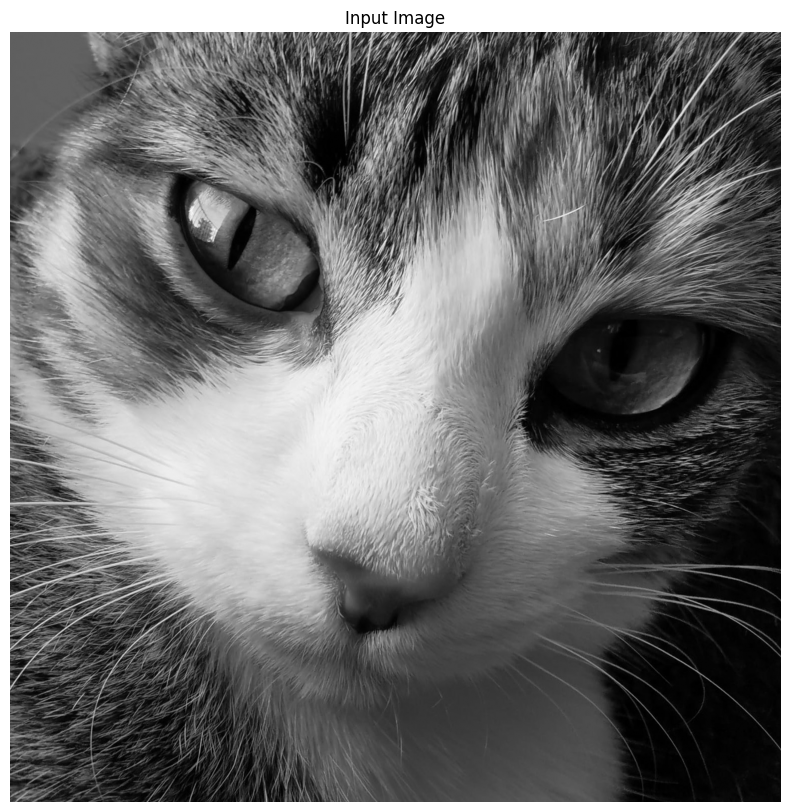

In [14]:
import cv2

# Load your image as a grayscale
input_image = cv2.imread('Trudy_for_compression.jpeg', cv2.IMREAD_GRAYSCALE)
# Display the original image
show_image(input_image, 'Input Image')

If you use some wavelet function (Biorthogonal 1.3 in this case), the 1-level 2D wavelet decomposition of our input image is given as follows:

In [15]:
# # You can see a list of wavelet families
import pywt
pywt.families()

['haar',
 'db',
 'sym',
 'coif',
 'bior',
 'rbio',
 'dmey',
 'gaus',
 'mexh',
 'morl',
 'cgau',
 'shan',
 'fbsp',
 'cmor']

In [16]:
# For each family, you can list the available wavelets
pywt.wavelist(family='bior', kind='all')

['bior1.1',
 'bior1.3',
 'bior1.5',
 'bior2.2',
 'bior2.4',
 'bior2.6',
 'bior2.8',
 'bior3.1',
 'bior3.3',
 'bior3.5',
 'bior3.7',
 'bior3.9',
 'bior4.4',
 'bior5.5',
 'bior6.8']

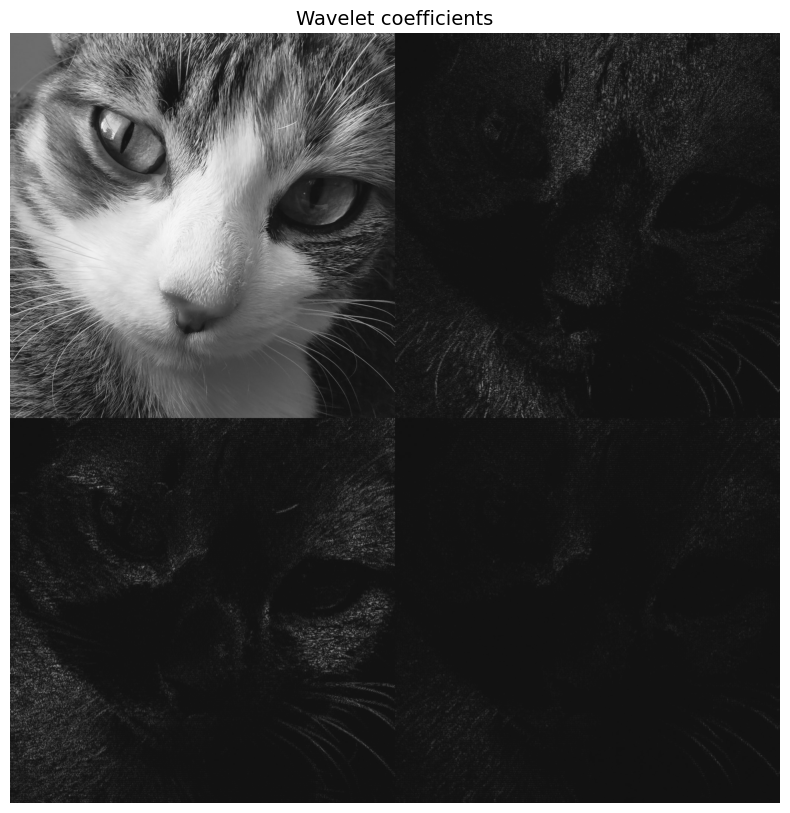

In [96]:
# 2. Compute the 1-level 2D Discrete Wavelet Transform
# We use the Haar wavelet ('db1').
# pywt.dwt2 returns: Approximation, (Horizontal details, Vertical details, Diagonal details)
coeffs2 = pywt.dwt2(input_image, 'db6')
cA, (cH, cV, cD) = coeffs2

# 3. Apply threshold/scaling for visualization purposes
# To make the edges pop out as white on a black background, 
# we take the absolute value and multiply by a factor.
# We then use np.clip to keep the values within the valid 0-255 pixel range.
visual_factor = 4.0  # Increase this to make edges brighter, decrease to make them darker
cH_vis = np.clip(np.abs(cH) * visual_factor, 0, 255)
cV_vis = np.clip(np.abs(cV) * visual_factor, 0, 255)
cD_vis = np.clip(np.abs(cD) * visual_factor, 0, 255)

# 4. Construct the 2x2 unified grid image
# Top row: Approximation (Left) | Horizontal Details (Right)
# Bottom row: Vertical Details (Left) | Diagonal Details (Right)
# Note: We use cV for the top-right to match the visual orientation of horizontal edges
top_row = np.hstack((cA, cV_vis))
bottom_row = np.hstack((cH_vis, cD_vis))

# Stack the two rows vertically to form the final single image
wavelet_grid = np.vstack((top_row, bottom_row))

# 5. Plot the result exactly like the screenshot
plt.figure(figsize=(10, 10))
plt.imshow(wavelet_grid, cmap='gray')
plt.title('Wavelet coefficients', fontsize=14)
plt.axis('off') # Hide axes for a clean look
plt.show()

In the previous image we applied a threshold in the wavelet coefficients for visualization purposes. **Please explain the meaning of each of these 4 images**.

**YOUR ANSWER HERE:**

The generated image displays the four sub-bands of a single-level 2D Discrete Wavelet Transform (DWT). The transform applies low-pass (L) and high-pass (H) filters along the rows and columns of the image to separate different frequency components:

1. **Top-Left (Approximation / LL):** This quadrant is formed by applying a low-pass filter both horizontally and vertically. It represents the "coarse" or blurred version of the original image. It contains the low-frequency information, preserving the overall shape, illumination, and base structure of the subject.
2. **Top-Right (Horizontal Details / HL):** This is the result of a high-pass filter vertically and a low-pass filter horizontally. It captures high-frequency variations along the vertical axis, thereby highlighting the **horizontal edges** of the image.
3. **Bottom-Left (Vertical Details / LH):** This is the result of a low-pass filter vertically and a high-pass filter horizontally. It captures high-frequency variations along the horizontal axis, highlighting the **vertical edges** and contours of the image.
4. **Bottom-Right (Diagonal Details / HH):** This is formed by applying a high-pass filter in both directions. It isolates the highest frequencies, capturing **diagonal edges**, fine textures, and high-frequency noise.


In the original mathematical decomposition, the wavelet representation is extremely **sparse**. This means that in the detail sub-bands (HL, LH, HH), the vast majority of coefficients are exactly zero or very close to zero, because they correspond to the flat, smooth areas of the original image where there are no edges.
If we were to plot the raw detail coefficients directly as pixels, the three detail quadrants would appear almost entirely dark.
By applying a **thresholding and scaling technique** (taking the absolute value and amplifying it), we force the few significant coefficients (the actual high-frequency edges) to map to high pixel intensities. This is the *sparsity* concept: it makes the isolated edges "pop out" clearly against the black background of near-zero coefficients.


Now, you should compute the six-levels 2D wavelet decomposition of the input image with a Daubechies wavelet with six vanishing moments using the PyWavelet library. Please check https://pywavelets.readthedocs.io/en/latest/ref/2d-dwt-and-idwt.html#d-multilevel-decomposition-using-wavedec2

In [32]:
# Your code here
#six levels of decomposition of Daubechies wavelet
coeffs = pywt.wavedec2(input_image, wavelet='db6', level=6)

* Set a threshold of value of 100 and take to zero the values less than that in the 2D wavelet decomposition. **Note:** You should only threshold the outputs of the high-pass filters.



In [ ]:
# Your code here
# threshold of high-pass filters 
threshold = 100
# Keep approximation coefficients unchanged
cA = coeffs[0]       #Save the low-pass filter output

# Threshold only detail coefficients
new_coeffs = [cA]

for (cH, cV, cD) in coeffs[1:]:    # Loop ONLY through high-pass details

    cH_thr = pywt.threshold(cH, threshold, mode="hard")
    cV_thr = pywt.threshold(cV, threshold, mode="hard")
    cD_thr = pywt.threshold(cD, threshold, mode="hard")

    new_coeffs.append((cH_thr, cV_thr, cD_thr))

* Compute the IDWT to reconstruct the image after the "compression". Check https://pywavelets.readthedocs.io/en/latest/ref/2d-dwt-and-idwt.html#d-multilevel-reconstruction-using-waverec2 as a reference.

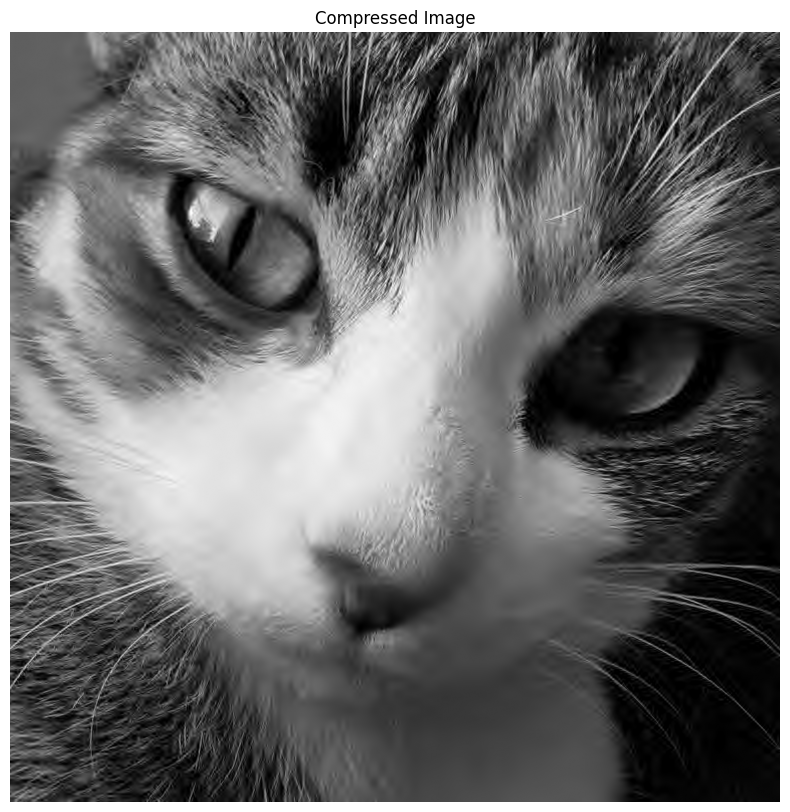

In [34]:
# Your code here
reconstructed = pywt.waverec2(new_coeffs, wavelet="db6")
compressed_image = np.clip(reconstructed, 0, 255)

#plot compressed image
show_image(compressed_image, 'Compressed Image')

What's the compression ratio?

In [ ]:
# Your code here
total_coef = input_image.size
#retained_coefficients
r_coef = np.count_nonzero(new_coeffs[0])

for details in new_coeffs[1:]:
    cH, cV, cD = details
    r_coef += np.count_nonzero(cH)
    r_coef += np.count_nonzero(cV)
    r_coef += np.count_nonzero(cD)

compression_ratio = total_coef/r_coef

print("Total coefficients:", total_coef)
print("Non-zero coefficients:", r_coef)
print(f"Compression ratio: {compression_ratio:.2f}", )


Total coefficients: 2345492
Non-zero coefficients: 29327
Compression ratio: 79.98




**The Compression Process:**
1. **Multilevel Decomposition:** We applied a 6-level 2D Discrete Wavelet Transform (DWT) using the `db6` wavelet. This separates the image into one core Approximation band (low frequencies) and many Detail bands (high frequencies).
2. **Thresholding:** To compress the data, we exploited the sparsity by applying a hard threshold of `100`. We forced all detail coefficients smaller than 100 to zero. We deliberately *did not* threshold the Approximation coefficients, as they contain the fundamental structure of the image.
3. **Reconstruction:** We then reconstructed the image using the Inverse DWT (`waverec2`). The result looks very similar to the original, proving that we can throw away a lot of mathematical data without losing much visual quality.

**The Compression Ratio:**
To measure our success, we calculate the Compression Ratio:
`Compression Ratio = Total Original Pixels / Retained Non-Zero Coefficients`

This ratio tells us how much data we saved. For example, a target ratio of "10:1" means that for every 10 pixels in the original image, we only need to store 1 non-zero wavelet coefficient. **Note on the 79.98:1 Ratio obtained:**
Achieving a ratio of roughly 80:1 demonstrates the extreme sparsity of the wavelet domain when using a high threshold. It means we are keeping only 1 coefficient for every ~80 original pixels. Such aggressive compression usually introduces visual artifacts, clearly highlighting the fundamental trade-off between maximizing data reduction and preserving image quality.

# **Putting everything together**

In this exercise we'll analyze the Peak Signal to Noise Ration (PSNR) of the compressed images for different thresholds. For doing so, we'll give you the function to compute the PSNR between the original and compressed image.

In [79]:
def psnr(original_image, compressed_image):
    h,w = original_image.shape
    mse = np.sum(np.abs(original_image-compressed_image)**2)/(h*w)
    return 20* np.log10(255**2/mse)

Now, you have to create a function codec that receives the input image, the wavelet to be used, the number of levels, and the threshold value. This function returns the compressed image and the compression ratio. **Note:** You already did that previously.

In [ ]:
def codec(input_image,wavelet='db4',num_levels=6,threshold=100, mode="hard"):
    # Your code here
    coeffs = pywt.wavedec2(input_image, wavelet=wavelet, level=num_levels)
    # Keep approximation coefficients unchanged
    cA = coeffs[0]

    # Threshold only detail coefficients
    new_coeffs = [cA]

    for (cH, cV, cD) in coeffs[1:]:

        cH_thr = pywt.threshold(cH, threshold, mode=mode)
        cV_thr = pywt.threshold(cV, threshold, mode=mode)
        cD_thr = pywt.threshold(cD, threshold, mode=mode)

        new_coeffs.append((cH_thr, cV_thr, cD_thr))
    h, w = input_image.shape
    # Reconstruct the image from thresholded coefficients
    reconstructed = pywt.waverec2(new_coeffs, wavelet=wavelet)
    compressed_image = np.clip(reconstructed[:h, :w], 0, 255)
    
    #compression ratio

    total_coef = input_image.size       
    r_coef = np.count_nonzero(new_coeffs[0])     # Count non-zero in approximation

    for details in new_coeffs[1:]:
        cH, cV, cD = details
        r_coef += np.count_nonzero(cH)
        r_coef += np.count_nonzero(cV)
        r_coef += np.count_nonzero(cD)

    compression_ratio = total_coef/r_coef
  
    return compressed_image, compression_ratio

Now, we compare the performance of the 'db4' and the 'bior1.3' wavelets in terms of compression ratio and PSNR for different thresholds.

In [81]:
def compare_wavelet(input_image, wavelets, thresholds, num_levels=6):
    #dictionary to save the results
    result = {}
    for wavelet in wavelets:
        result[wavelet] = {"CR": [],"PSNR": [] }
        for t in thresholds:
            compressed_image, compression_ratio = codec(input_image=input_image, wavelet=wavelet, num_levels=num_levels, threshold=t)
            psnr_value = psnr(original_image=input_image, compressed_image=compressed_image)
            result[wavelet]["CR"].append(compression_ratio)
            result[wavelet]["PSNR"].append(psnr_value)
    return result



In [90]:
wavelet_1 = 'db4'
wavelet_2 = 'bior1.3'
thresholds = [5,10,20,40,80,100]
num_levels=6
result = compare_wavelet(input_image=input_image, wavelets=[wavelet_1, wavelet_2], num_levels=num_levels, thresholds= thresholds)
for wavelet in result:
    print("="*90)
    print("Wavelet: ", wavelet)
    print("="*90)
    for i, t in enumerate(thresholds):
        print( 
            "Threshold: ", t,
            "  | Compression Ratio: ", result[wavelet]["CR"][i],
            "  | PSNR: ", result[wavelet]["PSNR"][i])

Wavelet:  db4
Threshold:  5   | Compression Ratio:  3.7210363411085887   | PSNR:  89.15205385478005
Threshold:  10   | Compression Ratio:  6.099252640721459   | PSNR:  78.57140279035089
Threshold:  20   | Compression Ratio:  11.550790656902674   | PSNR:  68.91074118240299
Threshold:  40   | Compression Ratio:  25.251841005985963   | PSNR:  60.73058178292936
Threshold:  80   | Compression Ratio:  61.54047175504421   | PSNR:  53.91417961058692
Threshold:  100   | Compression Ratio:  86.85077390209582   | PSNR:  51.81327552481954
Wavelet:  bior1.3
Threshold:  5   | Compression Ratio:  2.7771762811404757   | PSNR:  88.78545171822275
Threshold:  10   | Compression Ratio:  4.325720187377817   | PSNR:  77.28412675298065
Threshold:  20   | Compression Ratio:  7.823966002074834   | PSNR:  67.0164306404162
Threshold:  40   | Compression Ratio:  17.707171976445718   | PSNR:  58.07611120779009
Threshold:  80   | Compression Ratio:  48.56996127642832   | PSNR:  51.48897147796841
Threshold:  100   |

**QUESTIONS**

1) Which wavelet is better for the Trudy_for_compression.jpeg image and why?

# **Supplementary Exercises**

For the following exercises, you're free to use AI-assisted tools like agents. These exercises are open-ended. You should discuss and analyze your results. In this section, only the results and your discussion will be graded, not the code.

1. Designing and using custom filters with the pyWavelets library
Reference (https://pywavelets.readthedocs.io/en/latest/ref/wavelets.html#wavelet-families)
2. Propose and explore custom wavelets that achieve equivalent or higher compression ratio on the Trudy image explored previously. **P.S** You are free to explore any approach here.

In [91]:

# 1. CUSTOM WAVELET DEFINITION
# We propose a custom biorthogonal filter bank, 
# optimized for energy compaction in the low-frequency band.

dec_lo = [-0.010597, 0.032883, 0.030841, -0.187035, -0.027984, 0.630881, 0.714847, 0.230378]
dec_hi = [-0.230378, 0.714847, -0.630881, -0.027984, 0.187035, 0.030841, -0.032883, -0.010597]
rec_lo = [0.230378, 0.714847, 0.630881, -0.027984, -0.187035, 0.030841, 0.032883, -0.010597]
rec_hi = [-0.010597, -0.032883, 0.030841, 0.187035, -0.027984, -0.630881, 0.714847, -0.230378]

filter_bank = [dec_lo, dec_hi, rec_lo, rec_hi]
custom_biorth = pywt.Wavelet(name="custom_biorth", filter_bank=filter_bank)
custom_biorth.orthogonal = False
custom_biorth.biorthogonal = True
wavelets_to_test = ['db4', 'bior1.3',custom_biorth ]

result = compare_wavelet(input_image=input_image, wavelets=wavelets_to_test, num_levels=num_levels, thresholds= thresholds)
for wavelet in result:
    print("="*90)
    print("Wavelet: ", wavelet)
    print("="*90)
    for i, t in enumerate(thresholds):
        print( 
            "Threshold: ", t,
            "  | Compression Ratio: ", result[wavelet]["CR"][i],
            "  | PSNR: ", result[wavelet]["PSNR"][i])


Wavelet:  db4
Threshold:  5   | Compression Ratio:  3.7210363411085887   | PSNR:  89.15205385478005
Threshold:  10   | Compression Ratio:  6.099252640721459   | PSNR:  78.57140279035089
Threshold:  20   | Compression Ratio:  11.550790656902674   | PSNR:  68.91074118240299
Threshold:  40   | Compression Ratio:  25.251841005985963   | PSNR:  60.73058178292936
Threshold:  80   | Compression Ratio:  61.54047175504421   | PSNR:  53.91417961058692
Threshold:  100   | Compression Ratio:  86.85077390209582   | PSNR:  51.81327552481954
Wavelet:  bior1.3
Threshold:  5   | Compression Ratio:  2.7771762811404757   | PSNR:  88.78545171822275
Threshold:  10   | Compression Ratio:  4.325720187377817   | PSNR:  77.28412675298065
Threshold:  20   | Compression Ratio:  7.823966002074834   | PSNR:  67.0164306404162
Threshold:  40   | Compression Ratio:  17.707171976445718   | PSNR:  58.07611120779009
Threshold:  80   | Compression Ratio:  48.56996127642832   | PSNR:  51.48897147796841
Threshold:  100   |

# **Challenge: Wavelet Compression Design**

In this challenge, you will use wavelets to compress an image. The goal is not only to obtain a reconstructed image, but to make design choices and justify them. You may use `pywt` for this part.

---

## Objective

You are given a target compression ratio:

$
\text{compression ratio} \geq 10:1.
$

Your goal is to find a wavelet-based compression strategy that gives the best possible reconstruction quality while satisfying this constraint. You should experiment with:

- the wavelet family,
- the number of decomposition levels,
- the thresholding strategy,
- the threshold value.

---

## Available wavelets

Test at least four different wavelets, for example:

```python
wavelets = ["haar", "db2", "db4", "bior1.3", "bior2.2"]

In [86]:
# ==========================================
# EXPERIMENT SETUP
# ==========================================

wavelets = ["haar", "db2", "db4", "bior1.3", "bior2.2", "sym4", "coif3", "rbio3.3"]
levels = [3, 4, 6]
strategies = ["hard", "soft"]
threshold_grid = [10,15, 20,25, 30,35, 40,45, 50,55, 60,65, 70, 75, 80]

best_config = None
best_psnr = -1
valid_results = []

print("Running Grid Search for Optimal Wavelet Configuration...\n")

for wl in wavelets:
    for lvl in levels:
        for strat in strategies:
            for t in threshold_grid:
                try:
                    comp_img, cr = codec(input_image, wl, lvl, t, mode=strat)
                    psnr_val = psnr(input_image, comp_img)
                    
                    # Filter for configurations meeting the challenge constraint
                    if cr >= 10.0:
                        valid_results.append({
                            "wavelet": wl, "levels": lvl, "strategy": strat, 
                            "threshold": t, "CR": cr, "PSNR": psnr_val
                        })
                        
                        # Track the absolute best quality configuration
                        if psnr_val > best_psnr:
                            best_psnr = psnr_val
                            best_config = valid_results[-1]
                except ValueError:
                    # Catch instances where level is too high for image size/filter length
                    continue

print("="*60)
print(f"OPTIMAL DESIGN CHOICE (CR >= 10:1)")
print("="*60)
if best_config:
    print(f"Wavelet Family:      {best_config['wavelet']}")
    print(f"Decomposition Lvl:   {best_config['levels']}")
    print(f"Thresholding Type:   {best_config['strategy'].upper()}")
    print(f"Threshold Value:     {best_config['threshold']}")
    print(f"Achieved CR:         {best_config['CR']:.2f}:1")
    print(f"Maximized PSNR:      {best_config['PSNR']:.2f} dB")
else:
    print("No configuration met the CR >= 10:1 constraint. Try increasing threshold values.")
print("="*60)

Running Grid Search for Optimal Wavelet Configuration...

OPTIMAL DESIGN CHOICE (CR >= 10:1)
Wavelet Family:      coif3
Decomposition Lvl:   3
Thresholding Type:   HARD
Threshold Value:     20
Achieved CR:         10.77:1
Maximized PSNR:      69.62 dB
